In [3]:
from datasets import load_dataset
from transformers import AutoTokenizer
from tqdm.auto import tqdm
import numpy as np
import matplotlib.pyplot as plt

## Analysis of metamathqa

In [4]:
# Load the full training split (≈395 K rows). Remove streaming=True if you prefer an in-memory Dataset.
ds = load_dataset("meta-math/MetaMathQA", split="train")
ds = ds.select(range(50_000))

# Qwen 2.5-0.5 B tokenizer (trust_remote_code=True is required for custom fast-tokenizer code)
tok = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-0.5B", trust_remote_code=True)

Generating train split: 100%|██████████| 395000/395000 [00:03<00:00, 129007.60 examples/s]


In [5]:
# tokenize the responses
lens = []

for ex in tqdm(ds, desc="Tokenising MetaMathQA"):
    text = (ex.get("response", "")).strip()
    lens.append(len(tok.encode(text)))

lens = np.asarray(lens, dtype=np.uint32)

Tokenising MetaMathQA: 100%|██████████| 50000/50000 [00:15<00:00, 3290.85it/s]


In [6]:
print(f"Examples analysed : {lens.size:_}")
print(f"Min tokens        : {lens.min():_}")
print(f"Max tokens        : {lens.max():_}")
print(f"Average tokens    : {lens.mean():,.2f}")
print(f"Median tokens     : {np.median(lens):_}")

Examples analysed : 50_000
Min tokens        : 4
Max tokens        : 2_002
Average tokens    : 176.42
Median tokens     : 150.0


In [20]:
# Print percentiles of the token length distribution
percentiles = [0.01, 0.10, 0.25, 0.50, 0.75, 0.85, 0.90, 0.99]
vals = np.quantile(lens, percentiles)

print("Token-length percentiles (Qwen 2.5-0.5 B tokenizer)")
for p, v in zip(percentiles, vals):
    print(f" {p:>5.2%}  →  {int(v):_} tokens")


Token-length percentiles (Qwen 2.5-0.5 B tokenizer)
 1.00%  →  51 tokens
 10.00%  →  81 tokens
 25.00%  →  107 tokens
 50.00%  →  150 tokens
 75.00%  →  218 tokens
 85.00%  →  264 tokens
 90.00%  →  299 tokens
 99.00%  →  550 tokens


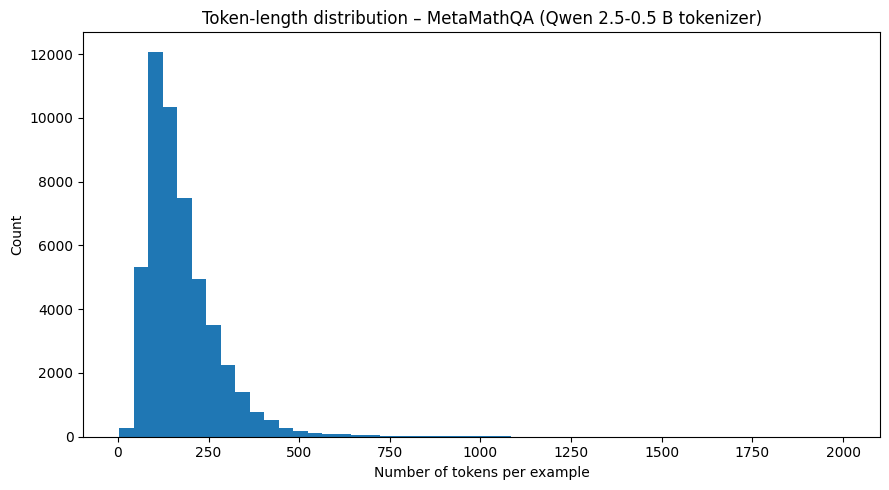

In [7]:
plt.figure(figsize=(9,5))
# 50 equal-width bins give a clear overview; adjust as you like.
plt.hist(lens, bins=50)
plt.title("Token-length distribution – MetaMathQA (Qwen 2.5-0.5 B tokenizer)")
plt.xlabel("Number of tokens per example")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [9]:
# check the response with the highest number of tokens
# ─── 6️⃣ Show the 5 longest examples ───────────────────────────────────────────
from heapq import nlargest

top5 = []

for ex in tqdm(ds, desc="Collecting longest examples"):
    text   = ex.get("response", "")
    length = len(tok.encode(text))

    top5.append((length, ex))           # push current example
    if len(top5) > 5:                   # keep only the 5 largest
        top5 = nlargest(5, top5, key=lambda x: x[0])

# Sort so rank-1 is the absolute longest
top5 = sorted(top5, key=lambda x: x[0], reverse=True)

for rank, (length, ex) in enumerate(top5, 1):
    print(f"\n====== TOP {rank} – {length} tokens ======\n")
    print("■ Question:\n", ex.get("query", "(none)"))
    print("\n■ Answer:\n",   ex.get("response",   "(none)"))



====== TOP 1 – 2002 tokens ======

■ Question:
 We define two sequences of vectors $(\mathbf{v}_n)$ and $(\mathbf{w}_n)$ as follows: First, $\mathbf{v}_0 = \begin{pmatrix} 1 \\ X \end{pmatrix},$ $\mathbf{w}_0 = \begin{pmatrix} 4 \\ 0 \end{pmatrix}.$  Then for all $n \ge 1,$ $\mathbf{v}_n$ is the projection of $\mathbf{w}_{n - 1}$ onto $\mathbf{v}_0,$ and $\mathbf{w}_n$ is the projection of $\mathbf{v}_n$ onto $\mathbf{w}_0.$  Find
\[\mathbf{v}_1 + \mathbf{v}_2 + \mathbf{v}_3 + \dotsb.\]
If we know the answer to the above question is \begin{pmatrix}4/9\4/3\end{pmatrix}, what is the value of unknown variable X?

■ Answer:
 We are given the sequences of vectors $(\mathbf{v}_n)$ and $(\mathbf{w}_n)$, and we want to find the sum of $\mathbf{v}_1 + \mathbf{v}_2 + \mathbf{v}_3 + \dotsb$.
We can start by finding the formulas for $\mathbf{v}_n$ and $\mathbf{w}_n$ in terms of $\mathbf{v}_0$ and $\mathbf{w}_0$.
Given that $\mathbf{v}_n$ is the projection of $\mathbf{w}_{n-1}$ onto $\mathbf{v}_0$

In [22]:
# Example schedule for latent replacement
lats_added_per_epoch = [2,3,4,5,6,7,8,9,10]
print(f"Number of epochs: {len(lats_added_per_epoch)}")
print(f"Total lat added: {sum(lats_added_per_epoch)}")
print(f"Total tokens replaced: {sum(lats_added_per_epoch)*5}")

Number of epochs: 9
Total lat added: 54
Total tokens replaced: 270
